In [ ]:
import pandas as pd

main_df=pd.read_csv('../data/processed/final_data.csv')
main_df

,booking_id,customer_id,service_id,customer_name,phone,email,payment_status,payment_id,payment_amount,payment_method,customer_rating,scheduled_date,payment_date
0,1,39,3,Elizabeth Fowler,747510799,elizabethfowler@gmail.com,COMPLETED,1.0,300.0,Transfer,3.0,2026-02-01 06:26:51,2026-02-02 06:48:57
1,2,29,3,Zachary Hicks,761333872,zacharyhicks@gmail.com,CANCELLED,NaN,NaN,NaN,NaN,2026-01-23 21:18:24,NaN
2,3,15,2,Dylan Miller,722691669,dylanmiller@gmail.com,CANCELLED,NaN,NaN,NaN,NaN,2026-02-17 03:53:32,NaN
3,4,43,1,Sherry Decker,724493534,sherrydecker@gmail.com,CANCELLED,NaN,NaN,NaN,NaN,2026-02-14 05:40:00,NaN
4,5,8,1,Gina Moore,741316475,ginamoore@gmail.com,COMPLETED,2.0,150.0,Cash,5.0,2026-02-12 03:08:46,2026-02-13 03:30:52
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,37,3,Sherri Baker,739909169,sherribaker@gmail.com,CANCELLED,NaN,NaN,NaN,NaN,2026-02-12 19:14:01,NaN
196,197,33,1,Tricia Valencia,784746872,triciavalencia@gmail.com,COMPLETED,67.0,150.0,Cash,1.0,2026-03-19 14:11:32,2026-03-20 14:33:38
197,198,42,1,Fred Smith,828412411,fredsmith@gmail.com,CANCELLED,NaN,NaN,NaN,NaN,2026-02-11 20:10:16,NaN
198,199,44,1,Anthony Humphrey,794016400,anthonyhumphrey@gmail.com,PENDING,NaN,NaN,NaN,NaN,2026-01-22 03:47:00,NaN


In [3]:
#descriptive statistics
print(main_df.info())
print(main_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   booking_id       200 non-null    int64  
 1   customer_id      200 non-null    int64  
 2   service_id       200 non-null    int64  
 3   customer_name    200 non-null    object 
 4   phone            200 non-null    int64  
 5   email            200 non-null    object 
 6   payment_status   200 non-null    object 
 7   payment_id       67 non-null     float64
 8   payment_amount   67 non-null     float64
 9   payment_method   67 non-null     object 
 10  customer_rating  67 non-null     float64
 11  scheduled_date   200 non-null    object 
 12  payment_date     67 non-null     object 
dtypes: float64(3), int64(4), object(6)
memory usage: 20.4+ KB
None
       booking_id  customer_id  service_id         phone  payment_id  \
count  200.000000   200.000000  200.000000  2.000000e+02   67.000

In [4]:
#CONVERT DATES TO DATETIME DATA TYPE
main_df['payment_date']=pd.to_datetime(main_df['payment_date'],errors='coerce')
print(main_df['payment_date'].dtype)
main_df['scheduled_date']=pd.to_datetime(main_df['scheduled_date'],errors='coerce')
print(main_df['scheduled_date'].dtype)


datetime64[ns]
datetime64[ns]


In [93]:
#KEY PERFORMANCE INDICATORS (KPIs)
#REVENUE METRICS

#TOTAL REVENUE
total_revenue=main_df['payment_amount'].sum()
print(f'TOTAL REVENUE:\n {total_revenue}')

#REVENUE PER DAY
revenue_per_day=pd.DataFrame(main_df.groupby(main_df['payment_date'].dt.date)['payment_amount'].sum())
print(f'\nFIRST 5 DAYS OF DAILY REVENUE:\n{revenue_per_day.head(5)}')

#AVERAGE REVENUE IN A DAY
average_revenue_per_day=revenue_per_day['payment_amount'].mean()
print(f'AVERAGE REVENUE IN A DAY:')
print(average_revenue_per_day)

#REVENUE PER WEEK
revenue_per_week=main_df.set_index('payment_date')['payment_amount'].resample('W').sum()
print(f'\nFIRST 5 WEEKS OF WEEKLY REVENUE:\n{revenue_per_week.head(5)}')

#AVERAGE REVENUE IN A WEEK
average_revenue_per_week=revenue_per_week.mean()
print(f'AVERAGE REVENUE IN A WEEK:\n{average_revenue_per_week}')

#REVENUE PER MONTH
revenue_per_month=main_df.set_index('payment_date')['payment_amount'].resample('M').sum()
print(f'\nFIRST FEW MONTHS OF MONTHLY REVENUE:\n{revenue_per_month.head(5)}')
#AVERAGE REVENUE PER MONTH
average_revenue_per_month=revenue_per_month.mean()
print(f'AVERAGE REVENUE IN A MONTH:\n{average_revenue_per_month}')



TOTAL REVENUE:
 14590.0

FIRST 5 DAYS OF DAILY REVENUE:
              payment_amount
payment_date                
2026-01-24             220.0
2026-01-26             300.0
2026-01-29             670.0
2026-01-30             450.0
2026-01-31             370.0
AVERAGE REVENUE IN A DAY:
331.59090909090907

FIRST 5 WEEKS OF WEEKLY REVENUE:
payment_date
2026-01-25     220.0
2026-02-01    2090.0
2026-02-08    2310.0
2026-02-15    1710.0
2026-02-22    2310.0
Name: payment_amount, dtype: float64
AVERAGE REVENUE IN A WEEK:
1459.0

FIRST FEW MONTHS OF MONTHLY REVENUE:
payment_date
2026-01-31    2010.0
2026-02-28    8410.0
2026-03-31    4170.0
Name: payment_amount, dtype: float64
AVERAGE REVENUE IN A MONTH:
4863.333333333333


In [95]:
import os
os.makedirs('../data/analytics',exist_ok=True)
revenue_per_day.to_csv('../data/analytics/revenue_datasets/daily_revenue.csv',index=False)
revenue_per_month.to_csv('../data/analytics/revenue_datasets/monthly_revenue.csv',index=False)
revenue_per_week.to_csv('../data/analytics/revenue_datasets/weekly_revenue.csv',index=False)

revenue_summary=pd.DataFrame(
    {
        'total_revenue':[total_revenue],
        'average_revenue_per_day':[average_revenue_per_day],
        'average_revenue_per_week':[average_revenue_per_week],
        'average_revenue_per_month':[average_revenue_per_month]
    }
)
revenue_summary.to_csv('../data/analytics/revenue_datasets/revenue_summary.csv',index=False)


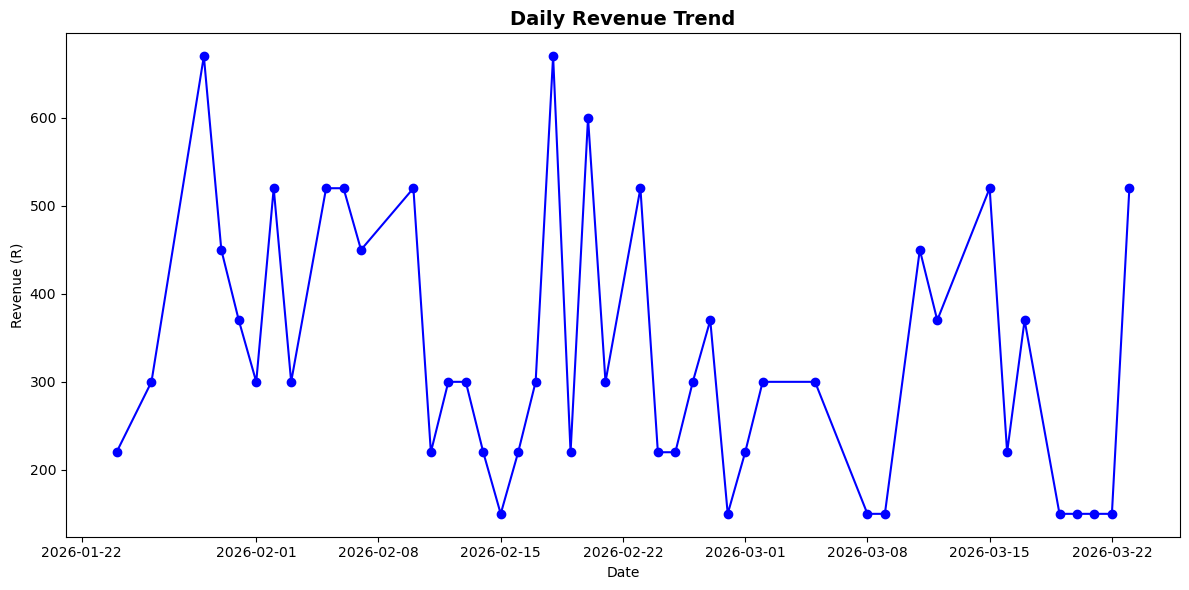

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#REVENUE PER DAY
plt.figure(figsize=(12,6))
plt.plot(revenue_per_day.index, revenue_per_day.values, color='blue',marker='o')
plt.title('Daily Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (R)')
plt.tight_layout()
plt.show()

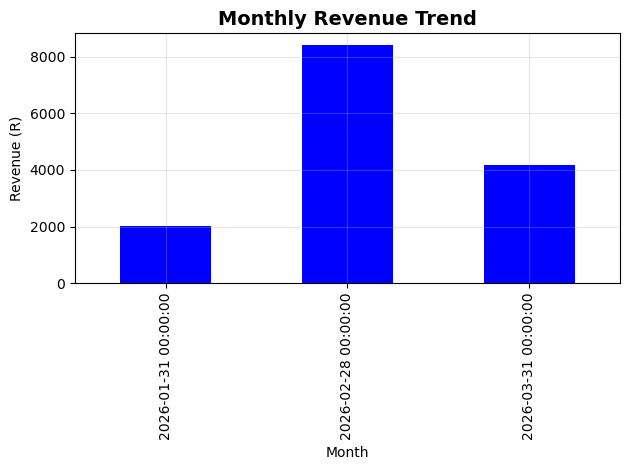

In [35]:
%matplotlib inline

plt.Figure(figsize=(12,5))

revenue_per_month.plot(kind='bar',color='blue')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (R)')
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

In [104]:
#REVENUE INSIGHT!!

#BUSINESS GENERATES 331.59 ON AVERAGE DAILY
average_revenue_per_day=average_revenue_per_day
average_revenue_per_week=average_revenue_per_week
#THEORICAL WEEKLY REVENUE: 331.59 * 7 DAYS= 2321.13
theorical_average_revenue_per_week=average_revenue_per_day*7

#operational days estimation approximates 4.4 days
operational_days_estimation=average_revenue_per_week/average_revenue_per_day
print(operational_days_estimation)
#1)The business likely operates on only about 1459/331.59=4.4 DAYS per week

#revenue gap
revenue_gap=theorical_average_revenue_per_week-average_revenue_per_week
revenue_gap_percentage=(revenue_gap/theorical_average_revenue_per_week)*100

print(revenue_gap)
print(revenue_gap_percentage)
#2) The business might be experiencing payment delays

revenue_insights=pd.DataFrame({
    'average_revenue_per_day':[average_revenue_per_day],
    'average_revenue_per_week':[average_revenue_per_week],
    'theorical_average_revenue_per_week':[theorical_average_revenue_per_week],
    'operational_days_estimation':[operational_days_estimation],
    'revenue_gap':[revenue_gap],
    'revenue_gap_percentage':[revenue_gap_percentage],
    'missing_revenue_days':[7-operational_days_estimation]

})
revenue_insights

revenue_insights.to_csv('../data/analytics/revenue_datasets/revenue_insights.csv',index=False)


4.4
862.1363636363635
37.14285714285714


In [124]:
#CUSTOMER METRICS

total_customers=main_df['customer_id'].nunique()


#DETECTING THE NO. OF TIMES EACH CUSTOMER HAD A BOOKING 
#.reset_index(name='booking_count'):transforms result from Series back into a flat DataFrame.
repeat_customers=main_df.groupby('customer_id').size().reset_index(name='booking_count')
print(repeat_customers.head())

#CUSTOMER WITH THE MOST BOOKINGS
top_customer=repeat_customers.loc[repeat_customers['booking_count'].idxmax()]
top_customer
top_customer_id=top_customer['customer_id']
top_customer_count=top_customer['booking_count']
print(f'customer {top_customer_id} has the most bookings: {top_customer_count} bookings')

#CUSTOMER REPEAT RATE
customers_with_multiple=len(repeat_customers[repeat_customers['booking_count']>1])
repeat_rate=(customers_with_multiple/total_customers)*100

#AVERAGE BOOKINGS PER CUSTOMER
avg_bookings_per_customer=repeat_customers['booking_count'].mean()
customer_metrics=pd.DataFrame(
    {
        'total_customers':[total_customers],
        'top_customer':[top_customer_id],
        'top_customer_count':[top_customer_count],
        'repeat_rate': [repeat_rate]
    }
)
customer_metrics.to_csv('../data/analytics/customer_metrics/customer_metrics.csv',index=False)

   customer_id  booking_count
0            1              5
1            2              5
2            3              4
3            4              4
4            5              2
customer 44 has the most bookings: 10 bookings


In [130]:
#BOOKING PERFORMANCE

#(df["status"] == "COMPLETED"), you get a Boolean Series,True = 1 , False = 0

completion_rate = ((main_df["payment_status"] == "COMPLETED").mean())*100
completion_rate =pd.DataFrame({completion_rate},columns=['booking_completion_rate'])
completion_rate
#COMPLETION RATE OF 33.5% IS QUITE LOW AND RAISES CONCERNS
# ONLY 1 OUT OF 3 BOOKINGS IS BEING COMPLETED
#SUGGESTS SERIOUS ISSUES WITH PAYMENT PROCESS OR CUSTOMER COMMITMENT

completion_rate.to_csv('../data/analytics/KPIs/completion_rate.csv',index=False)

In [136]:
#SERVICE PERFORMANCE
service_revenue = (main_df.groupby("service_id")["payment_amount"].sum())
service_revenue
service_count=main_df.groupby('service_id')['booking_id'].count()
service_count

service_performance=pd.DataFrame({
    'service_revenue':service_revenue,
    'service_count':service_count
})
service_performance
service_performance.to_csv('../data/analytics/KPIs/service_performance.csv', index=False)

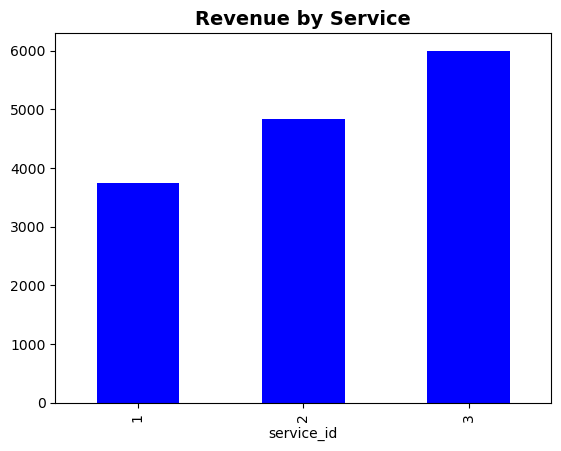

In [40]:
service_revenue.plot(kind='bar',color='blue')
plt.title("Revenue by Service", fontsize=14, fontweight='bold')
plt.show()

In [158]:
#CUSTOMER VALUE METRICS
customer_value=main_df.groupby('customer_id')['payment_amount'].sum().reset_index(name='total_amount_paid')
print(customer_value.head(5))
customer_value.to_csv('../data/analytics/customer_metrics/customer_value_metrics.csv',index=False)

#TOP CUSTOMER
best_customer=customer_value.loc[customer_value['total_amount_paid'].idxmax()]
best_customer

average_customer_value=customer_value['total_amount_paid'].mean()
print(average_customer_value)
print(best_customer['customer_id'])

top_customer_metrics=pd.DataFrame({
    'best_customer':[best_customer['customer_id']],
    'customer_total_payment':[best_customer['total_amount_paid']],
    'average_customer_value':average_customer_value
})
top_customer_metrics

top_customer_metrics.to_csv('../data/analytics/customer_metrics/top_customer_metrics.csv',index=False)


   customer_id  total_amount_paid
0            1              370.0
1            2              450.0
2            3              370.0
3            4              150.0
4            5              300.0
297.7551020408163
39.0


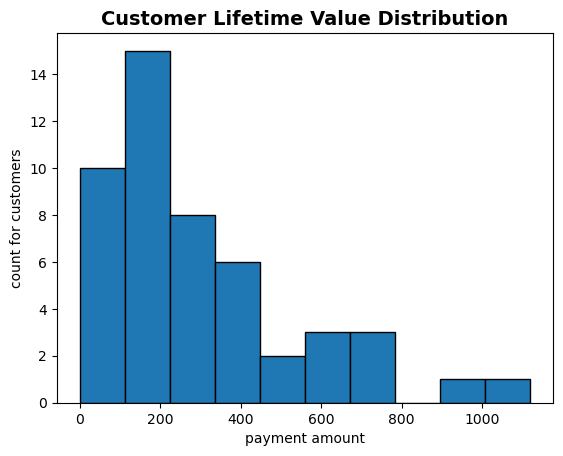

In [ ]:
#customer value visualization
#defines revenue concentration

customer_value.plot(kind='hist',edgecolor='black',bins=10)
plt.title('Customer Lifetime Value Distribution', fontsize=14,fontweight='bold')
plt.xlabel('payment amount')
plt.ylabel('count for customers')
plt.show()

In [168]:
#TIME ANALYSIS

#PAYMENT DELAYS
main_df['payment_delays']=(main_df['payment_date']-main_df['scheduled_date']).dt.days
main_df.head()
#CUSTOMERS WITH (+2 days) DELAYS
late_customer=main_df[main_df['payment_delays']>=2]

late_customer.to_csv('../data/analytics/time_analysis/late_customer.csv',index=False)

#DELAY STATISTICS
avg_delay = main_df['payment_delays'].mean()
max_delay = main_df['payment_delays'].max()
percentage_on_time = (main_df['payment_delays'] <= 0).mean() * 100
percentage_late = (main_df['payment_delays'] >= 2).mean() * 100

delay_statistics=pd.DataFrame(
    {
        'avg_delay':[avg_delay],
        'max_delay':[max_delay],
        'percentage_on_time':[percentage_on_time],
        'percentage_late':[percentage_late]
        
    }
)
delay_statistics

delay_statistics.to_csv('../data/analytics/time_analysis/delay_statistics.csv',index=False)

In [171]:
#HEATMAP INTELLIGENCE
#DEMAND CONCENTRATION

main_df['booking_day']=main_df['scheduled_date'].dt.day_name()
main_df['booking_hour']=main_df['scheduled_date'].dt.hour

#HEATMAP DATA
#ROWS-->DAYS, COLUMNS-->HOURS, COUNT_VALUES-->BOOKING_ID
#Where do most bookings happen, and where do they not?

#When customers interact with your system
heatmap_booking_data=main_df.pivot_table(index='booking_day',
                                         columns='booking_hour',
                                         values='customer_id',
                                         aggfunc='count',
                                         fill_value=0)

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

#Fix day ordering
heatmap_booking_data = heatmap_booking_data.reindex(day_order)
heatmap_booking_data.to_csv('../data/analytics/heatmap/heatmap_booking_data.csv',index=False)
# plt.figure(figsize=(16,6))
# sns.heatmap(heatmap_booking_data,fmt='d',cmap='Blues',linewidths=0.05,linecolor='gray')
# plt.title('Booking Heatmap', fontsize=14,fontweight='bold')
# plt.tight_layout()
# plt.show()



In [172]:
#REVENUE HEATMAP
heatmap_revenue=main_df.pivot_table(index='booking_day',
                                         columns='booking_hour',
                                         values='payment_amount',
                                         aggfunc='sum',
                                         fill_value=0)
heatmap_booking_data.to_csv('../data/analytics/heatmap/heatmap_revenue.csv',index=False)
# plt.figure(figsize=(16,6))
# sns.heatmap(heatmap_revenue,fmt='d',cmap='Blues',linewidths=0.05,linecolor='gray')
# plt.title('Booking Heatmap', fontsize=14,fontweight='bold')
# plt.tight_layout()
# plt.show()

